Device: cpu
ROOT utilise: /kaggle/input/datasets/ANONYMIZED_USER
OUTPUT_ROOT utilise: /kaggle/working
VIT_EXTRACTOR_PATH: /kaggle/input/datasets/ANONYMIZED_USER/nouveau-dossier-2/Nouveau dossier (2)/vit3d_extractor_trained_seed42.pt
IMAGE_BASE: /kaggle/input/datasets/ANONYMIZED_USER/dataimage/dataimage/imagedataset/image
Checkpoints 'global_model_complete' trouves:
   numero=0 -> /kaggle/input/datasets/ANONYMIZED_USER/nouveau-dossier-2/Nouveau dossier (2)/global_model_complete  (dossier=True)
   numero=1 -> /kaggle/input/datasets/ANONYMIZED_USER/nouveau-dossier-2/Nouveau dossier (2)/global_model_complete(1)  (dossier=True)
   numero=2 -> /kaggle/input/datasets/ANONYMIZED_USER/nouveau-dossier-2/Nouveau dossier (2)/global_model_complete(2)  (dossier=True)
Fichiers/dossiers 'test_model_inputs' trouves:
   horizon=T4 -> /kaggle/input/datasets/ANONYMIZED_USER/nouveau-dossier-2/Nouveau dossier (2)/test_model_inputs T4  (dossier=True)
   horizon=T2 -> /kaggle/input/datasets/ANONYMIZED_USER/no

/tmp/ipykernel_58/589073593.py:1161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


[9/9] patients traites | lignes OK: 9 | echecs: 0

TERMINE. Lignes generees avec succes: 9 | echecs: 0
PNG individuels (pour VLM): /kaggle/working/FED_ATTENTION_ROLLOUT_RESULTS/vlm_images
Resume CSV: /kaggle/working/FED_ATTENTION_ROLLOUT_RESULTS/ALL_PATIENTS_ATTENTION_GRAD_ROLLOUT_summary_PREVIEW.csv
Resume JSON: /kaggle/working/FED_ATTENTION_ROLLOUT_RESULTS/ALL_PATIENTS_ATTENTION_GRAD_ROLLOUT_summary_PREVIEW.json
Details interface: /kaggle/working/FED_ATTENTION_ROLLOUT_RESULTS/INTERFACE_XAI_PATIENT_DETAILS_PREVIEW.json


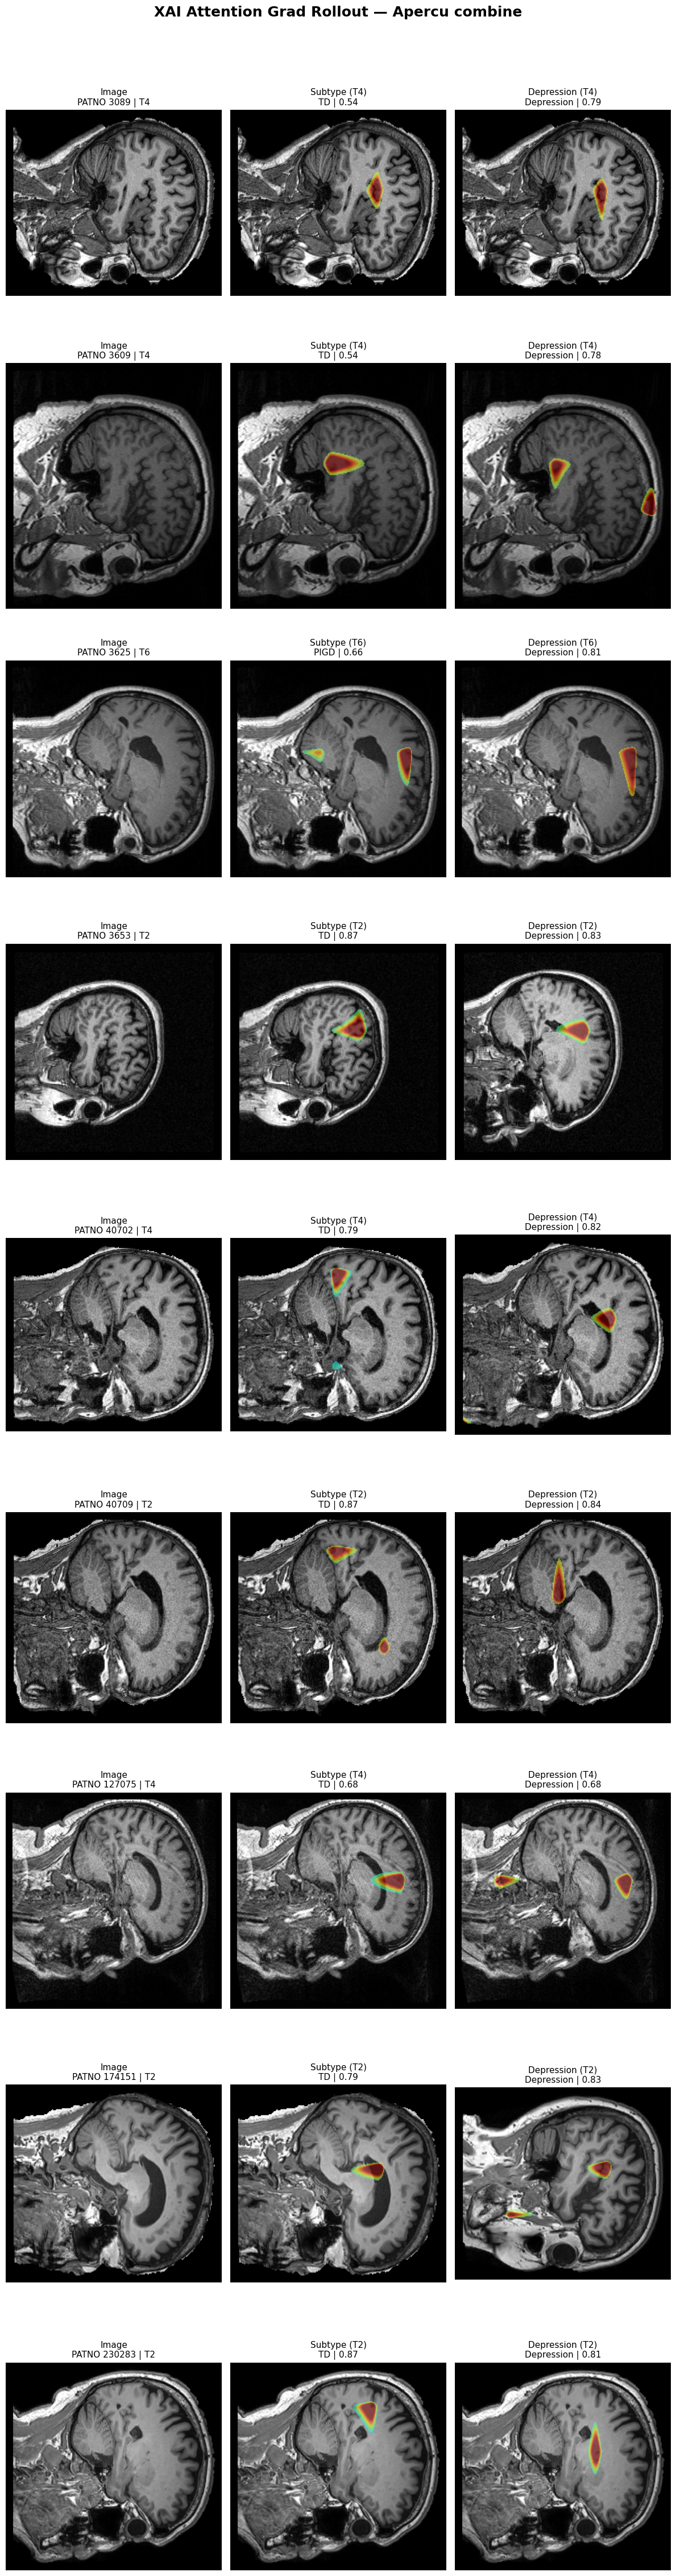

Apercu combine sauvegarde: /kaggle/working/FED_ATTENTION_ROLLOUT_RESULTS/COMBINED_PREVIEW_ATTENTION_GRAD_ROLLOUT_3089_3609_3625_3653_40702_40709_etc.png

######################################################################
ETAPE 2/2 : TOUS LES PATIENTS (sans affichage, PNG + CSV/JSON uniquement)
######################################################################
Traitement de 105 patients / 113 lignes (patient x temps) au total.
[10/105] patients traites | lignes OK: 10 | echecs: 0
[20/105] patients traites | lignes OK: 21 | echecs: 0
[30/105] patients traites | lignes OK: 32 | echecs: 0
[40/105] patients traites | lignes OK: 43 | echecs: 0
[49/105] FAILED PATNO 101555 [T4]: Nombre insuffisant de slices DICOM: 1
[50/105] patients traites | lignes OK: 53 | echecs: 1
[60/105] patients traites | lignes OK: 66 | echecs: 1
[69/105] FAILED PATNO 147191 [T2]: Nombre insuffisant de slices DICOM: 1
[70/105] patients traites | lignes OK: 75 | echecs: 2
[74/105] FAILED PATNO 157041 [T2]: Nom

In [ ]:
# ============================================================
# XAI ATTENTION ROLLOUT - VERSION MULTI-TEMPS / TOUS PATIENTS / PNG POUR VLM
# ============================================================
# CORRECTIF APPLIQUE (voir bloc 7-BIS et section 9) :
#   L'IndexError ("boolean index did not match indexed array along axis 0")
#   venait du fait que chaque tache (subtype / depression) choisit sa PROPRE
#   coupe "hotspot" (get_hotspot_slice) et son PROPRE crop (crop_to_brain),
#   qui dependent de sa propre heatmap. Le code original forcait ensuite
#   `img = img_sub` pour composer l'overlay de depression avec `heat_dep`,
#   alors que ces deux tableaux pouvaient avoir des tailles differentes
#   (ex: 196 lignes pour img_sub vs 191 lignes pour heat_dep).
#
#   Correction : on garde chaque image appariee a SA PROPRE heatmap de bout
#   en bout (img_sub+heat_sub d'un cote, img_dep+heat_dep de l'autre), au
#   lieu de melanger les deux. `save_vlm_images_for_patient_horizon` prend
#   desormais (img_sub, heat_sub, img_dep, heat_dep) explicitement.
#
#   Consequence a connaitre : mri.png (base sur la coupe "subtype") et
#   xai_depression.png (base sur la coupe "depression") peuvent representer
#   des coupes anatomiques legerement differentes du meme patient/temps, car
#   chaque tache met en evidence des zones differentes du cerveau. C'est le
#   comportement attendu du pipeline original (chaque CAM a son propre
#   hotspot) ; seule l'incoherence de tailles qui faisait planter le code a
#   ete corrigee, pas la logique de selection de coupe elle-meme.
# ============================================================
#
# Modifications par rapport a la version "notebook" avec MANUAL_PATIENTS :
#
# 1) MANUAL_PATIENTS = [] par defaut -> TOUS les patients valides sont traites
#    automatiquement (au lieu d'une liste figee de 12 patients).
#
# 2) Chaque image XAI (IRM brute, overlay Subtype, overlay Depression) est
#    desormais sauvegardee comme un fichier PNG INDIVIDUEL, propre (sans
#    titre/axes matplotlib), dans un dossier dedie par patient/temps.
#    C'est ce format qui est exploitable directement par un VLM (une image
#    = un fichier), au lieu d'une seule grande figure combinant tout le
#    monde (illisible/inutilisable telle quelle en entree d'un VLM, et
#    potentiellement enorme/lente a generer si il y a beaucoup de patients).
#
# 3) La grande figure combinee (grid) matplotlib est conservee mais devient
#    OPTIONNELLE (MAKE_COMBINED_FIGURE), desactivee par defaut des qu'il y a
#    beaucoup de patients, pour ne pas exploser memoire/temps. Le vrai
#    livrable pour le VLM, ce sont les PNG individuels + le CSV/JSON de
#    metadonnees (predictions, confidences, chemins des fichiers).
#
# Le reste (extracteur ViT3D, Attention Grad Rollout, modele federe
# MultitaskLateFusionIRMParallel, pretraitement DICOM, mise en forme des
# cartes de chaleur) est IDENTIQUE au notebook original.
# ============================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import math
import json
import shutil
import zipfile
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy.ndimage import zoom, gaussian_filter, distance_transform_edt
from scipy.ndimage import binary_opening, binary_closing, binary_fill_holes, binary_erosion, binary_dilation, label

device = torch.device("cpu")
print("Device:", device)


# ============================================================
# 1) INPUT : AUTO-DETECTION DU ROOT (Kaggle OU dossier local)
# ============================================================

CANDIDATE_ROOTS = [
    "/kaggle/input/datasets/ANONYMIZED_USER",
    "/mnt/user-data/uploads/Nouveau_dossier__2_/Nouveau dossier (2)",
    "/mnt/user-data/uploads",
]


def find_file(root, filename):
    matches = []
    for r, _, files in os.walk(root):
        for f in files:
            if f == filename:
                matches.append(os.path.join(r, f))
    return matches


def find_contains(root, text, ext=None):
    matches = []
    for r, _, files in os.walk(root):
        for f in files:
            if text.lower() in f.lower() and (ext is None or f.endswith(ext)):
                matches.append(os.path.join(r, f))
    return matches


def find_dirs_contains(root, text):
    matches = []
    for r, dirs, _ in os.walk(root):
        for d in dirs:
            if text.lower() in d.lower():
                matches.append(os.path.join(r, d))
    return matches


ROOT = None
for cand in CANDIDATE_ROOTS:
    if os.path.exists(cand) and len(find_contains(cand, "vit3d_extractor", ".pt")) > 0:
        ROOT = cand
        break

if ROOT is None:
    raise FileNotFoundError(
        "Aucune racine d'input valide trouvee. Ajoutez votre chemin dans CANDIDATE_ROOTS."
    )

print("ROOT utilise:", ROOT)

# IMPORTANT : sur Kaggle, seul ce qui est ecrit dans /kaggle/working/ est
# capture par l'onglet "Output" du notebook. Un chemin fixe comme
# /mnt/user-data/outputs (propre a un autre environnement) donnerait un
# run "Successfully ran" mais un Output a 0 B, car Kaggle ne suit pas ce
# dossier. On detecte donc automatiquement le bon dossier de sortie.
CANDIDATE_OUTPUT_ROOTS = [
    "/kaggle/working",
    "/mnt/user-data/outputs",
]

OUTPUT_ROOT = None
for cand in CANDIDATE_OUTPUT_ROOTS:
    if os.path.exists(cand):
        OUTPUT_ROOT = cand
        break
if OUTPUT_ROOT is None:
    OUTPUT_ROOT = CANDIDATE_OUTPUT_ROOTS[0]
    os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("OUTPUT_ROOT utilise:", OUTPUT_ROOT)

OUT_DIR = Path(OUTPUT_ROOT) / "FED_ATTENTION_ROLLOUT_RESULTS"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Dossier dedie aux PNG individuels prets pour le VLM
VLM_IMAGES_DIR = OUT_DIR / "vlm_images"
VLM_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

vit_paths = find_file(ROOT, "vit3d_extractor_trained_seed42.pt")
if len(vit_paths) == 0:
    vit_paths = find_contains(ROOT, "vit3d_extractor", ".pt")
if len(vit_paths) == 0:
    raise FileNotFoundError("vit3d_extractor_trained_seed42.pt introuvable")
VIT_EXTRACTOR_PATH = vit_paths[0]

IMAGE_BASE = os.path.join(ROOT, "dataimage/dataimage/imagedataset/image")
if not os.path.exists(IMAGE_BASE):
    candidates = []
    for r, dirs, files in os.walk(ROOT):
        if os.path.basename(r) == "image":
            candidates.append(r)
    IMAGE_BASE = candidates[0] if candidates else None

print("VIT_EXTRACTOR_PATH:", VIT_EXTRACTOR_PATH)
print("IMAGE_BASE:", IMAGE_BASE if IMAGE_BASE else "INTROUVABLE (les IRM DICOM ne sont pas dans cet input)")


# ============================================================
# 1-BIS) RESOLUTION DES 3 TEMPS (HORIZONS) : T2, T4, T6
# ============================================================

import re

SUFFIX_NUMBER_TO_HORIZON = {0: "T2", 1: "T4", 2: "T6"}

MONTH_TO_INDEX = {0: 0, 12: 1, 24: 2, 36: 3, 48: 4, 60: 5}
HORIZON_MONTHS = {
    "T2": [0, 12],
    "T4": [0, 12, 24, 36],
    "T6": [0, 12, 24, 36, 48, 60],
}


def find_numbered_candidates(root, base_name):
    pattern = re.compile(
        r"^" + re.escape(base_name.lower()) + r"\s*(?:\((\d+)\))?$"
    )
    found = []
    for r, dirs, files in os.walk(root):
        for name in list(dirs) + list(files):
            full = os.path.join(r, name)
            is_dir = os.path.isdir(full)
            stem = name if is_dir else os.path.splitext(name)[0]
            m = pattern.match(stem.lower().strip())
            if m:
                number = int(m.group(1)) if m.group(1) else 0
                found.append((number, full, is_dir))
    return found


def materialize_checkpoint(path_or_dir):
    if os.path.isfile(path_or_dir):
        return path_or_dir

    if os.path.isdir(path_or_dir) and os.path.exists(os.path.join(path_or_dir, "data.pkl")):
        rebuilt_path = os.path.join(
            "/home/claude/work/_rebuilt_ckpts",
            os.path.basename(path_or_dir.rstrip("/")).replace(" ", "_") + ".pt",
        )
        os.makedirs(os.path.dirname(rebuilt_path), exist_ok=True)

        if not os.path.exists(rebuilt_path):
            base_arcname = "archive"
            with zipfile.ZipFile(rebuilt_path, "w", compression=zipfile.ZIP_STORED) as zf:
                for r, _, files in os.walk(path_or_dir):
                    for f in files:
                        full = os.path.join(r, f)
                        rel = os.path.relpath(full, path_or_dir)
                        arcname = os.path.join(base_arcname, rel)
                        zf.write(full, arcname)
        return rebuilt_path

    raise FileNotFoundError(f"Checkpoint introuvable ou format inconnu: {path_or_dir}")


class NpzLike:
    def __init__(self, folder):
        self._folder = folder
        self.files = [f[:-4] for f in os.listdir(folder) if f.endswith(".npy")]

    def __getitem__(self, key):
        return np.load(os.path.join(self._folder, key + ".npy"), allow_pickle=True)


def materialize_npz(path, is_dir):
    if is_dir:
        npy_files = [f for f in os.listdir(path) if f.endswith(".npy")]
        if len(npy_files) == 0:
            for sub in os.listdir(path):
                sub_path = os.path.join(path, sub)
                if os.path.isdir(sub_path) and any(f.endswith(".npy") for f in os.listdir(sub_path)):
                    return NpzLike(sub_path)
            return None
        return NpzLike(path)

    if path.lower().endswith(".npz"):
        return np.load(path, allow_pickle=True)

    extract_dir = os.path.join(
        "/home/claude/work/_npz_extract",
        os.path.splitext(os.path.basename(path))[0].replace(" ", "_"),
    )
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(path, "r") as zf:
            zf.extractall(extract_dir)

    return NpzLike(extract_dir)


def find_horizon_named_candidates(root, base_name):
    pattern = re.compile(
        r"^" + re.escape(base_name.lower()) + r"[ _]*(t[246])?$"
    )
    found = []
    for r, dirs, files in os.walk(root):
        for name in list(dirs) + list(files):
            full = os.path.join(r, name)
            is_dir = os.path.isdir(full)
            stem = name if is_dir else os.path.splitext(name)[0]
            m = pattern.match(stem.lower().strip())
            if m:
                horizon = m.group(1).upper() if m.group(1) else "T2"
                found.append((horizon, full, is_dir))
    return found


def resolve_all_horizons(root):
    ckpt_candidates = find_numbered_candidates(root, "global_model_complete")
    npz_candidates = find_horizon_named_candidates(root, "test_model_inputs")

    print("Checkpoints 'global_model_complete' trouves:")
    for num, path, is_dir in ckpt_candidates:
        print(f"   numero={num} -> {path}  (dossier={is_dir})")
    print("Fichiers/dossiers 'test_model_inputs' trouves:")
    for horizon, path, is_dir in npz_candidates:
        print(f"   horizon={horizon} -> {path}  (dossier={is_dir})")

    ckpt_by_number = {}
    for num, path, is_dir in ckpt_candidates:
        if num not in ckpt_by_number or (ckpt_by_number[num][1] and not is_dir):
            ckpt_by_number[num] = (path, is_dir)

    npz_by_horizon = {}
    for horizon, path, is_dir in npz_candidates:
        prefer_current = (
            horizon not in npz_by_horizon
            or (not is_dir and path.lower().endswith(".npz"))
        )
        if prefer_current:
            npz_by_horizon[horizon] = (path, is_dir)

    resolved = {}
    for num, horizon in SUFFIX_NUMBER_TO_HORIZON.items():
        if num not in ckpt_by_number or horizon not in npz_by_horizon:
            continue
        ckpt_path_raw, _ = ckpt_by_number[num]
        try:
            ckpt_path = materialize_checkpoint(ckpt_path_raw)
        except FileNotFoundError:
            continue

        npz_path, npz_is_dir = npz_by_horizon[horizon]
        npz_data = materialize_npz(npz_path, npz_is_dir)
        if npz_data is None:
            continue

        resolved[horizon] = {
            "horizon": horizon,
            "ckpt_path": ckpt_path,
            "npz_data": npz_data,
        }

    return resolved


AVAILABLE_HORIZONS = resolve_all_horizons(ROOT)
for h in ["T2", "T4", "T6"]:
    if h in AVAILABLE_HORIZONS:
        print(f"Horizon {h}: DISPONIBLE  (ckpt={AVAILABLE_HORIZONS[h]['ckpt_path']})")
    else:
        print(f"Horizon {h}: absent de cet input (ignore)")

if len(AVAILABLE_HORIZONS) == 0:
    raise RuntimeError("Aucun horizon (T2/T4/T6) disponible dans cet input.")


# ============================================================
# 2) PREPARATION DES DONNEES CLINIQUES PAR HORIZON
# ============================================================

def prepare_horizon_clinical_data(horizon, npz_data):
    required = ["X_clinical_raw", "X_mri_flag", "patient_id"]
    for k in required:
        if k not in npz_data.files:
            raise KeyError(f"Cle manquante dans NPZ ({horizon}): {k}")

    X_feat_all = npz_data["X_clinical_raw"].astype(np.float32)
    X_mask_all = np.isfinite(X_feat_all).astype(np.float32)
    X_feat_all = np.nan_to_num(X_feat_all, nan=0.0, posinf=0.0, neginf=0.0)
    X_clinical_all = np.concatenate([X_feat_all, X_mask_all], axis=-1).astype(np.float32)

    mri_flag_all = npz_data["X_mri_flag"].astype(np.float32)
    mri_flag_all = np.nan_to_num(mri_flag_all, nan=1.0, posinf=1.0, neginf=0.0)

    patient_ids = npz_data["patient_id"].astype(float).astype(int)

    if "month_idx" in npz_data.files:
        month_idx_all = npz_data["month_idx"].astype(np.int64)
    else:
        _months = HORIZON_MONTHS[horizon]
        _base = np.array([MONTH_TO_INDEX[m] for m in _months], dtype=np.int64)
        month_idx_all = np.tile(_base, (X_clinical_all.shape[0], 1))

    return {
        "X_clinical_all": X_clinical_all,
        "mri_flag_all": mri_flag_all,
        "patient_ids": patient_ids,
        "month_idx_all": month_idx_all,
    }


HORIZON_DATA = {}
for h, info in AVAILABLE_HORIZONS.items():
    HORIZON_DATA[h] = prepare_horizon_clinical_data(h, info["npz_data"])
    print(f"[{h}] X_clinical_all:", HORIZON_DATA[h]["X_clinical_all"].shape,
          "| patients:", len(HORIZON_DATA[h]["patient_ids"]))


def get_patient_inputs(horizon, patno):
    hd = HORIZON_DATA[horizon]
    patno = int(float(patno))
    idxs = np.where(hd["patient_ids"] == patno)[0]
    if len(idxs) == 0:
        return None, None, None, None

    idx = int(idxs[0])

    clinical_input = torch.tensor(hd["X_clinical_all"][idx:idx + 1], dtype=torch.float32).to(device)

    mri_flag = torch.tensor(hd["mri_flag_all"][idx:idx + 1], dtype=torch.float32).to(device)
    if mri_flag.ndim == 1:
        mri_flag = mri_flag.view(1, 1)
    if mri_flag.shape[-1] != 1:
        mri_flag = mri_flag[:, :1]

    month_idx = torch.tensor(hd["month_idx_all"][idx:idx + 1], dtype=torch.long).to(device)

    return idx, clinical_input, mri_flag, month_idx


# ============================================================
# 3) ARCHITECTURES (identiques au notebook original)
# ============================================================

class ManualMultiheadSelfAttention(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.dropout = nn.Dropout(dropout)

        self.in_proj_weight = nn.Parameter(torch.empty(3 * embed_dim, embed_dim))
        self.in_proj_bias = nn.Parameter(torch.empty(3 * embed_dim))
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.in_proj_weight)
        nn.init.constant_(self.in_proj_bias, 0.0)
        nn.init.xavier_uniform_(self.out_proj.weight)
        nn.init.constant_(self.out_proj.bias, 0.0)

    def forward(self, x):
        B, N, C = x.shape
        qkv = F.linear(x, self.in_proj_weight, self.in_proj_bias)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        attn_probs.retain_grad()

        attn_drop = self.dropout(attn_probs)
        out = attn_drop @ v
        out = out.transpose(1, 2).contiguous().view(B, N, C)
        out = self.out_proj(out)

        return out, attn_probs


class PatchEmbed3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv3d(1, 128, kernel_size=16, stride=16)

    def forward(self, x):
        return self.proj(x)


class RolloutEncoderLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.self_attn = ManualMultiheadSelfAttention(embed_dim=128, num_heads=4, dropout=0.1)
        self.linear1 = nn.Linear(128, 512)
        self.dropout = nn.Dropout(0.1)
        self.linear2 = nn.Linear(512, 128)
        self.norm1 = nn.LayerNorm(128)
        self.norm2 = nn.LayerNorm(128)
        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.1)
        self.activation = nn.GELU()
        self.attn_weights = None

    def forward(self, src):
        attn_out, attn_w = self.self_attn(src)
        self.attn_weights = attn_w
        src = src + self.dropout1(attn_out)
        src = self.norm1(src)
        ff = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(ff)
        src = self.norm2(src)
        return src


class RolloutEncoder(nn.Module):
    def __init__(self, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList([RolloutEncoderLayer() for _ in range(num_layers)])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class ViT3DExtractorRollout(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbed3D()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 128))
        self.pos_embed = nn.Parameter(torch.zeros(1, 217, 128))
        self.encoder = RolloutEncoder(num_layers=4)
        self.norm = nn.LayerNorm(128)
        self.head = nn.Sequential(
            nn.Linear(256, 512), nn.GELU(), nn.Dropout(0.1), nn.Linear(512, 256)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        B, C, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm(x)
        cls_feat = x[:, 0]
        mean_feat = x[:, 1:].mean(dim=1)
        feat = torch.cat([cls_feat, mean_feat], dim=1)
        feat = self.head(feat)
        return feat


class TaskHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class MRIProjector(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(0.1),
        )

    def forward(self, x):
        return self.net(x)


class MultitaskLateFusionIRMParallel(nn.Module):
    def __init__(self, state, nhead=4):
        super().__init__()
        d_model = state["clinical_proj.0.weight"].shape[0]
        clin_dim = state["clinical_proj.0.weight"].shape[1]
        max_time = state["time_embed.weight"].shape[0]

        mri_input_dim = state["mri_projector.net.0.weight"].shape[1]
        mri_hidden = state["mri_projector.net.0.weight"].shape[0]
        mri_proj_dim = state["mri_projector.net.4.weight"].shape[0]

        ff_dim = state["transformer.layers.0.linear1.weight"].shape[0]

        layer_ids = [int(k.split(".")[2]) for k in state.keys() if k.startswith("transformer.layers.")]
        n_layers = max(layer_ids) + 1

        gru_hidden = state["gru.weight_hh_l0"].shape[1]

        fusion_dim = state["late_fusion.0.weight"].shape[1]
        shared_dim = state["late_fusion.0.weight"].shape[0]

        hidden_subtype = state["head_subtype.net.0.weight"].shape[0]
        hidden_dep = state["head_depbin.net.0.weight"].shape[0]
        hidden_levels = state["head_levels.net.0.weight"].shape[0]

        if d_model % nhead != 0:
            nhead = 4 if d_model % 4 == 0 else 2

        self.time_embed = nn.Embedding(max_time, d_model)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clin_dim, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(0.1),
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=0.1, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.tr_norm = nn.LayerNorm(d_model)

        attn_hidden = state["attn.0.weight"].shape[0]
        self.attn = nn.Sequential(
            nn.Linear(d_model, attn_hidden), nn.Tanh(), nn.Dropout(0.1), nn.Linear(attn_hidden, 1)
        )

        self.gru = nn.GRU(input_size=d_model, hidden_size=gru_hidden, num_layers=1,
                           batch_first=True, bidirectional=True)
        self.gru_norm = nn.LayerNorm(gru_hidden * 2)

        self.mri_projector = MRIProjector(mri_input_dim, mri_hidden, mri_proj_dim)
        self.mri_ctx_branch = nn.Sequential(
            nn.Linear(mri_proj_dim + 1, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(0.1),
        )

        self.late_fusion = nn.Sequential(
            nn.Linear(fusion_dim, shared_dim), nn.LayerNorm(shared_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(shared_dim, shared_dim), nn.LayerNorm(shared_dim), nn.GELU(), nn.Dropout(0.1),
        )

        self.head_subtype = TaskHead(shared_dim, hidden_subtype, 2)
        self.head_depbin = TaskHead(shared_dim, hidden_dep, 2)
        self.head_levels = TaskHead(shared_dim, hidden_levels, 4)

    def forward(self, x_clin, x_mri, x_flag, month_idx, return_features=False):
        B, T, _ = x_clin.shape
        if x_flag.ndim == 1:
            x_flag = x_flag.view(B, 1)
        if x_flag.shape[-1] != 1:
            x_flag = x_flag[:, :1]

        z_clin = self.clinical_proj(x_clin)
        z_clin = z_clin + self.time_embed(month_idx)

        z_tr = self.transformer(z_clin)
        z_tr = self.tr_norm(z_tr)
        attn_scores = self.attn(z_tr).squeeze(-1)
        attn_w = torch.softmax(attn_scores, dim=1)
        tr_ctx = torch.sum(z_tr * attn_w.unsqueeze(-1), dim=1)

        z_gru, _ = self.gru(z_clin)
        gru_last = self.gru_norm(z_gru[:, -1, :])

        z_mri = self.mri_projector(x_mri)
        mri_in = torch.cat([z_mri, x_flag], dim=1)
        mri_ctx = self.mri_ctx_branch(mri_in)

        fused = torch.cat([tr_ctx, gru_last, mri_ctx], dim=1)
        z_shared = self.late_fusion(fused)

        out_subtype = self.head_subtype(z_shared)
        out_depbin = self.head_depbin(z_shared)
        out_levels = self.head_levels(z_shared)

        if return_features:
            return out_subtype, out_depbin, out_levels, z_shared
        return out_subtype, out_depbin, out_levels


# ============================================================
# 4) CHARGEMENT DES MODELES PAR HORIZON (mise en cache)
# ============================================================

vit = ViT3DExtractorRollout().to(device)
vit_state = torch.load(VIT_EXTRACTOR_PATH, map_location=device)
vit.load_state_dict(vit_state, strict=True)
vit.eval()
print("ViT3D extractor (attention rollout) charge:", VIT_EXTRACTOR_PATH)

HORIZON_MODELS = {}


def load_horizon_model(horizon):
    if horizon in HORIZON_MODELS:
        return HORIZON_MODELS[horizon]

    info = AVAILABLE_HORIZONS[horizon]
    ckpt = torch.load(info["ckpt_path"], map_location="cpu")
    fed_state = ckpt["model_state_dict"]

    fed_nhead = 4
    best_params = ckpt.get("best_params", None) if isinstance(ckpt, dict) else None
    if isinstance(best_params, dict) and "nhead" in best_params:
        fed_nhead = int(best_params["nhead"])

    fed_model = MultitaskLateFusionIRMParallel(fed_state, nhead=fed_nhead).to(device)
    fed_model.load_state_dict(fed_state, strict=True)
    fed_model.eval()

    HORIZON_MODELS[horizon] = {"ckpt": ckpt, "fed_model": fed_model}
    print(f"Modele federe charge pour {horizon}:", info["ckpt_path"])
    return HORIZON_MODELS[horizon]


for h in AVAILABLE_HORIZONS:
    load_horizon_model(h)


# ============================================================
# 5) CHARGEMENT DICOM + PRETRAITEMENT (identique a l'original)
# ============================================================

def load_dicom_volume(patient_id):
    if IMAGE_BASE is None:
        raise FileNotFoundError(
            "IMAGE_BASE introuvable : aucun dossier d'images IRM (DICOM) n'a ete "
            "trouve dans cet input."
        )

    folder = os.path.join(IMAGE_BASE, str(int(float(patient_id))))
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Dossier IRM introuvable: {folder}")

    slices = []
    for root, _, files in os.walk(folder):
        for f in files:
            path = os.path.join(root, f)
            try:
                ds = pydicom.dcmread(path, force=True)
                img = ds.pixel_array.astype(np.float32)
                if hasattr(ds, "ImagePositionPatient"):
                    pos = float(ds.ImagePositionPatient[2])
                elif hasattr(ds, "SliceLocation"):
                    pos = float(ds.SliceLocation)
                else:
                    pos = len(slices)
                slices.append((pos, img))
            except Exception:
                pass

    if len(slices) < 20:
        raise ValueError(f"Nombre insuffisant de slices DICOM: {len(slices)}")

    slices = sorted(slices, key=lambda x: x[0])
    volume = np.stack([s[1] for s in slices], axis=0)
    return volume


def preprocess_mri(volume, target_shape=(96, 96, 96)):
    volume = volume.astype(np.float32)
    volume = volume - volume.min()
    volume = volume / (volume.max() + 1e-8)

    smooth = gaussian_filter(volume, sigma=3)
    volume = volume / (smooth + 1e-8)
    volume = volume - volume.min()
    volume = volume / (volume.max() + 1e-8)

    nonzero = volume[volume > 0]
    if len(nonzero) > 0:
        thr = np.percentile(nonzero, 20)
        mask = volume > thr
        mask = binary_opening(mask, iterations=1)
        mask = binary_closing(mask, iterations=3)
        mask = binary_fill_holes(mask)
        volume = volume * mask

    factors = [target_shape[i] / volume.shape[i] for i in range(3)]
    volume = zoom(volume, factors, order=1)

    volume = (volume - volume.mean()) / (volume.std() + 1e-8)
    p1, p99 = np.percentile(volume, [1, 99])
    volume = np.clip(volume, p1, p99)

    volume = volume - volume.min()
    volume = volume / (volume.max() + 1e-8)
    return volume


# ============================================================
# 6) ATTENTION GRAD ROLLOUT 
# ============================================================

def attention_grad_rollout_from_vit(vit_model):
    attn_mats = []
    for layer in vit_model.encoder.layers:
        attn = layer.attn_weights
        if attn is None:
            raise RuntimeError("Attention weights not found.")
        grad = attn.grad
        if grad is None:
            raise RuntimeError("Attention gradients are still None.")

        attn = attn[0]
        grad = grad[0]
        grad = torch.clamp(grad, min=0.0)
        weighted_attn = attn * grad
        weighted_attn = weighted_attn.mean(dim=0)
        weighted_attn = torch.clamp(weighted_attn, min=0.0)

        if float(weighted_attn.sum().detach().cpu()) <= 1e-12:
            weighted_attn = attn.mean(dim=0)

        eye = torch.eye(weighted_attn.size(0), device=weighted_attn.device)
        weighted_attn = weighted_attn + eye
        weighted_attn = weighted_attn / (weighted_attn.sum(dim=-1, keepdim=True) + 1e-8)
        attn_mats.append(weighted_attn)

    rollout = attn_mats[0]
    for attn in attn_mats[1:]:
        rollout = attn @ rollout

    cls_attention = rollout[0, 1:]
    cam = cls_attention.reshape(6, 6, 6).detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = zoom(cam, (16, 16, 16), order=1)
    cam = gaussian_filter(cam, sigma=0.8)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = np.power(cam, 2.5)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam


TASK_OUTPUT_INDEX = {"subtype": 0, "depression": 1, "levels": 2}


def predict_fed_and_attention_grad_rollout(patient_id, horizon, task="subtype", target_class=None):
    idx, clinical_input, mri_flag, month_idx = get_patient_inputs(horizon, patient_id)
    if idx is None:
        raise ValueError(f"Patient {patient_id} absent du NPZ pour {horizon}")

    volume_raw = load_dicom_volume(patient_id)
    volume_pre = preprocess_mri(volume_raw)
    mri_tensor = torch.tensor(volume_pre, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    fed_model = HORIZON_MODELS[horizon]["fed_model"]

    vit.eval()
    fed_model.eval()
    vit.zero_grad(set_to_none=True)
    fed_model.zero_grad(set_to_none=True)

    mri_feat = vit(mri_tensor)
    out_subtype, out_depbin, out_levels = fed_model(clinical_input, mri_feat, mri_flag, month_idx)
    outputs = (out_subtype, out_depbin, out_levels)

    logits = outputs[TASK_OUTPUT_INDEX[task]]
    probs_t = torch.softmax(logits, dim=1)
    probs = probs_t.detach().cpu().numpy()

    pred_class = int(np.argmax(probs))
    confidence = float(probs[0, pred_class])

    if target_class is None:
        target_class = pred_class

    score = logits[0, int(target_class)]
    score.backward()

    cam = attention_grad_rollout_from_vit(vit)

    return {
        "idx": idx,
        "patient_id": int(float(patient_id)),
        "horizon": horizon,
        "task": task,
        "volume_raw": volume_raw,
        "volume_pre": volume_pre,
        "cam": cam,
        "pred_class": pred_class,
        "target_class": int(target_class),
        "confidence": confidence,
        "probs": probs,
    }


# ============================================================
# 7) AFFICHAGE 
# ============================================================

def normalize01(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.nanmin(x)
    x = x / (np.nanmax(x) + 1e-8)
    return x


def normalize_mri_display(img):
    img = np.asarray(img, dtype=np.float32)
    vals = img[np.isfinite(img) & (img > 0)]
    if len(vals) == 0:
        return normalize01(img)
    lo, hi = np.percentile(vals, 1), np.percentile(vals, 99.5)
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-8)
    return img


def resize_cam_to_raw(cam_96, raw_shape):
    cam_96 = normalize01(cam_96)
    factors = tuple(raw_shape[i] / cam_96.shape[i] for i in range(3))
    cam_big = zoom(cam_96, factors, order=1)
    cam_big = gaussian_filter(cam_big, sigma=0.7)
    cam_big = normalize01(cam_big)
    cam_big = np.power(cam_big, 2.0)
    cam_big = normalize01(cam_big)
    return cam_big


def make_raw_brain_mask(volume_raw, sever_iter=6):
    vol = normalize01(volume_raw)
    nz = vol[vol > 0]
    if len(nz) == 0:
        return np.ones_like(vol, dtype=bool)

    thr = np.percentile(nz, 18)
    tissue_mask = vol > thr
    tissue_mask = binary_closing(tissue_mask, iterations=2)
    tissue_mask = binary_fill_holes(tissue_mask)

    eroded = binary_erosion(tissue_mask, iterations=sever_iter)
    lab, n = label(eroded)

    if n == 0:
        mask = binary_opening(tissue_mask, iterations=1)
        lab2, n2 = label(mask)
        if n2 > 0:
            sizes = np.bincount(lab2.ravel())
            sizes[0] = 0
            mask = lab2 == sizes.argmax()
        return mask.astype(bool)

    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    seed = lab == sizes.argmax()

    brain_mask = binary_dilation(seed, iterations=sever_iter)
    brain_mask = brain_mask & tissue_mask
    brain_mask = binary_fill_holes(brain_mask)

    if brain_mask.sum() < 500:
        brain_mask = tissue_mask

    return brain_mask.astype(bool)


def get_raw_slice(volume, axis, s):
    if axis == 0:
        return volume[s, :, :]
    elif axis == 1:
        return volume[:, s, :]
    else:
        return volume[:, :, s]


def get_hotspot_slice(volume_raw, cam_big, axis=0):
    vol = normalize01(volume_raw)
    n = vol.shape[axis]
    start = int(n * 0.25)
    end = int(n * 0.75)
    scores = []
    for s in range(start, end):
        img = get_raw_slice(vol, axis, s)
        heat = get_raw_slice(cam_big, axis, s)
        brain_area = np.sum(img > 0.10)
        if brain_area < 250:
            score = -1
        else:
            score = np.nanmax(heat) * 1000.0 + np.nansum(heat) * np.std(img) + brain_area * 0.001
        scores.append((score, s))
    scores.sort(reverse=True)
    return int(scores[0][1]) if len(scores) else int(n // 2)


def orient_like_reference(img, heat=None, flip_lr=True):
    img = np.rot90(img)
    if heat is not None:
        heat = np.rot90(heat)
    if flip_lr:
        img = np.fliplr(img)
        if heat is not None:
            heat = np.fliplr(heat)
    if heat is None:
        return img
    return img, heat


def crop_to_brain(img, heat=None, margin=8):
    if heat is None:
        mask = img > 0.04
    else:
        mask = (img > 0.04) | np.isfinite(heat)
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return img, heat
    y1 = max(0, ys.min() - margin)
    y2 = min(img.shape[0], ys.max() + margin)
    x1 = max(0, xs.min() - margin)
    x2 = min(img.shape[1], xs.max() + margin)
    if heat is None:
        return img[y1:y2, x1:x2], None
    return img[y1:y2, x1:x2], heat[y1:y2, x1:x2]


def make_inner_brain_mask(volume_raw, erosion_iter=3, min_distance=3):
    brain_mask = make_raw_brain_mask(volume_raw)
    inner = binary_erosion(brain_mask, iterations=erosion_iter)
    dist = distance_transform_edt(brain_mask)
    inner2 = dist >= float(min_distance)
    final_mask = inner & inner2
    if final_mask.sum() < 500:
        final_mask = inner
    if final_mask.sum() < 500:
        final_mask = brain_mask
    return final_mask.astype(bool)


def balanced_attention_heatmap_2d(heat2d, low_percentile=96, high_percentile=99.6,
                                   gamma=1.35, sigma=0.45, final_percentile=75):
    h = np.asarray(heat2d, dtype=np.float32)
    h = normalize01(h)
    vals = h[h > 0]
    if len(vals) == 0:
        return np.full_like(h, np.nan, dtype=np.float32)
    lo = np.percentile(vals, low_percentile)
    hi = np.percentile(vals, high_percentile)
    h = np.clip((h - lo) / (hi - lo + 1e-8), 0, 1)
    h = gaussian_filter(h, sigma=sigma)
    h = normalize01(h)
    h = np.power(h, gamma)
    vals2 = h[h > 0]
    if len(vals2) > 0:
        thr = np.percentile(vals2, final_percentile)
        h = np.where(h >= thr, h, np.nan)
    else:
        h[:] = np.nan
    return h


def make_2d_brain_mask(img2d, percentile=15, erosion_iter=3):
    img2d = np.asarray(img2d, dtype=np.float32)
    vals = img2d[img2d > 0]
    if len(vals) == 0:
        return np.zeros_like(img2d, dtype=bool)

    thr = np.percentile(vals, percentile)
    mask = img2d > thr
    mask = binary_opening(mask, iterations=2)
    mask = binary_closing(mask, iterations=3)
    mask = binary_fill_holes(mask)

    lab, n = label(mask)
    if n > 0:
        sizes = np.bincount(lab.ravel())
        sizes[0] = 0
        mask = lab == sizes.argmax()

    mask = binary_erosion(mask, iterations=erosion_iter)
    if mask.sum() < 200:
        mask = binary_erosion(mask, iterations=max(0, erosion_iter - 2))

    return mask.astype(bool)


def refine_2d_brain_mask(img2d, slice_inner_mask_3d, erosion_iter=2):
    base = np.asarray(slice_inner_mask_3d, dtype=bool)
    if base.sum() < 50:
        return make_2d_brain_mask(img2d, percentile=15, erosion_iter=erosion_iter)

    mask = binary_opening(base, iterations=1)
    mask = binary_closing(mask, iterations=2)
    mask = binary_fill_holes(mask)

    lab, n = label(mask)
    if n > 0:
        sizes = np.bincount(lab.ravel())
        sizes[0] = 0
        mask = lab == sizes.argmax()

    if erosion_iter > 0:
        eroded = binary_erosion(mask, iterations=erosion_iter)
        if eroded.sum() >= 200:
            mask = eroded

    return mask.astype(bool)


def filter_compact_hotspots(heat_show, max_aspect_ratio=4.0, min_fill_ratio=0.25, min_area=15):
    valid = np.isfinite(heat_show)
    if not valid.any():
        return heat_show

    lab, n = label(valid)
    if n == 0:
        return heat_show

    out = heat_show.copy()
    for i in range(1, n + 1):
        comp = lab == i
        area = int(comp.sum())
        if area < min_area:
            out[comp] = np.nan
            continue

        ys, xs = np.where(comp)
        h = ys.max() - ys.min() + 1
        w = xs.max() - xs.min() + 1
        aspect = max(h, w) / max(1, min(h, w))
        fill_ratio = area / float(h * w)

        if aspect > max_aspect_ratio or fill_ratio < min_fill_ratio:
            out[comp] = np.nan

    return out


def prepare_xai_views(result, axis=0, flip_lr=True):
    volume_raw = result["volume_raw"]
    cam_96 = result["cam"]

    raw_norm = normalize01(volume_raw)
    cam_big = resize_cam_to_raw(cam_96, raw_norm.shape)

    inner_mask = make_inner_brain_mask(raw_norm, erosion_iter=4, min_distance=4)
    cam_big = normalize01(cam_big * inner_mask)

    best_slice = get_hotspot_slice(raw_norm * inner_mask, cam_big, axis=axis)

    img = get_raw_slice(raw_norm, axis, best_slice)
    heat = get_raw_slice(cam_big, axis, best_slice)
    img = normalize_mri_display(img)

    heat_show = balanced_attention_heatmap_2d(heat)

    slice_inner_mask = get_raw_slice(inner_mask, axis, best_slice)
    slice_brain_mask = refine_2d_brain_mask(img, slice_inner_mask, erosion_iter=2)

    heat_show = np.where(slice_brain_mask, heat_show, np.nan)
    img = img * slice_brain_mask

    heat_show = filter_compact_hotspots(heat_show)

    img, heat_show = orient_like_reference(img, heat_show, flip_lr=flip_lr)
    img, heat_show = crop_to_brain(img, heat_show, margin=8)

    return img, heat_show, best_slice


# ============================================================
# 7-BIS) SAUVEGARDE PNG INDIVIDUELS (pour usage VLM) — VERSION CORRIGEE
# ============================================================

ALPHA_DEFAULT = 0.55


def composite_overlay_rgb(img, heat, cmap_name="jet", alpha=0.55):
    """
    Compose une image grayscale (img, deja normalisee [0,1]) avec une
    heatmap (heat, valeurs [0,1] ou NaN la ou il n'y a pas d'overlay) en
    utilisant la colormap `cmap_name`, et retourne une image RGB [0,1]
    prete a etre sauvegardee en PNG (sans decor matplotlib).

    IMPORTANT: `img` et `heat` DOIVENT provenir du meme appel a
    prepare_xai_views (meme coupe, meme crop) sinon leurs formes peuvent
    differer -> IndexError. Ne jamais melanger img_sub avec heat_dep (ou
    inversement).
    """
    img = normalize01(img)
    if img.shape != heat.shape:
        raise ValueError(
            f"Forme incompatible entre img {img.shape} et heat {heat.shape} : "
            f"ils doivent provenir du meme appel a prepare_xai_views."
        )

    rgb = np.stack([img, img, img], axis=-1)

    cmap = cm.get_cmap(cmap_name)
    heat_filled = np.nan_to_num(heat, nan=0.0)
    heat_rgb = cmap(np.clip(heat_filled, 0, 1))[..., :3]

    valid = np.isfinite(heat)
    out = rgb.copy()
    out[valid] = (1 - alpha) * rgb[valid] + alpha * heat_rgb[valid]
    out = np.clip(out, 0, 1)
    return out


def save_png_clean(array2d_or_rgb, path):
    """Sauvegarde une image (grayscale 2D ou RGB [0,1]) en PNG propre, sans axes/marges."""
    if array2d_or_rgb.ndim == 2:
        plt.imsave(path, array2d_or_rgb, cmap="gray", vmin=0, vmax=1)
    else:
        plt.imsave(path, array2d_or_rgb)


def save_vlm_images_for_patient_horizon(pid, horizon, img_sub, heat_sub, img_dep, heat_dep,
                                         alpha=ALPHA_DEFAULT):
    """
    Sauvegarde 3 PNG individuels (IRM seule, overlay Subtype, overlay
    Depression) pour un patient/temps donne, dans un dossier dedie.

    CORRECTIF: chaque overlay est desormais compose avec SA PROPRE image de
    coupe (img_sub pour l'overlay subtype, img_dep pour l'overlay
    depression), au lieu de forcer une seule `img` partagee. Les deux
    taches choisissent independamment leur "meilleure" coupe/crop
    (prepare_xai_views), donc leurs tailles (H, W) peuvent differer d'un
    patient/temps a l'autre -> il ne faut jamais composer heat_dep avec
    img_sub (ou l'inverse), sous peine d'IndexError.

    L'IRM "de reference" (mri.png) est basee sur la coupe choisie pour la
    tache subtype ; elle peut donc differer legerement de la coupe
    utilisee pour l'overlay depression (xai_depression.png), puisque
    chaque CAM met en evidence des zones potentiellement differentes.

    Retourne les chemins (relatifs a OUT_DIR) pour les mettre dans le CSV/JSON.
    """
    patient_img_dir = VLM_IMAGES_DIR / f"PATNO_{int(pid)}" / horizon
    patient_img_dir.mkdir(parents=True, exist_ok=True)

    mri_path = patient_img_dir / "mri.png"
    subtype_path = patient_img_dir / "xai_subtype.png"
    depression_path = patient_img_dir / "xai_depression.png"

    # IRM de reference : coupe utilisee pour la tache subtype
    save_png_clean(normalize01(img_sub), mri_path)

    overlay_sub = composite_overlay_rgb(img_sub, heat_sub, alpha=alpha)
    save_png_clean(overlay_sub, subtype_path)

    # heat_dep est TOUJOURS composee avec img_dep (sa propre image), jamais img_sub
    overlay_dep = composite_overlay_rgb(img_dep, heat_dep, alpha=alpha)
    save_png_clean(overlay_dep, depression_path)

    return {
        "mri_png": str(mri_path.relative_to(OUT_DIR)),
        "xai_subtype_png": str(subtype_path.relative_to(OUT_DIR)),
        "xai_depression_png": str(depression_path.relative_to(OUT_DIR)),
    }


# ============================================================
# 8) SELECTION DES PATIENTS + TEMPS DISPONIBLES
# ============================================================

CLASS_NAMES = {
    "subtype": ["TD", "PIGD"],
    "depression": ["No depression", "Depression"],
    "levels": ["None", "Mild", "Moderate", "Severe"],
}

DISPLAY_AXIS = 0
FLIP_LR = True

# --- CHANGEMENT PRINCIPAL ---
# Etape 1 (apercu) : ces patients sont traites EN PREMIER, avec la figure
# grille combinee construite ET affichee (plt.show), pour verifier
# visuellement que tout va bien avant de lancer le traitement complet.
PREVIEW_PATIENTS = [3089, 3609, 3625, 3653, 40702, 40709, 127075, 174151, 230283]

# Etape 2 (tout le monde) : TOUS les patients valides (NPZ + IRM
# disponibles) sont ensuite traites, SANS affichage ni figure grille -
# seulement les PNG individuels + CSV/JSON sont sauvegardes. Les patients
# deja traites en etape 1 (PREVIEW_PATIENTS) ne sont pas refaits.

# Au-dela de ce nombre total de lignes (patient x temps), on NE construit
# PLUS la grande figure combinee matplotlib (trop lente/lourde) pour un
# appel qui ne l'a pas explicitement demandee. Mettez None pour ne jamais
# la generer automatiquement.
MAX_ROWS_FOR_COMBINED_FIGURE = 40


def patient_has_mri(patno):
    if IMAGE_BASE is None:
        return False
    folder = os.path.join(IMAGE_BASE, str(int(float(patno))))
    return os.path.exists(folder)


def get_available_horizons_for_patient(patno):
    available = []
    for h in ["T2", "T4", "T6"]:
        if h not in HORIZON_DATA:
            continue
        if int(float(patno)) in HORIZON_DATA[h]["patient_ids"]:
            if patient_has_mri(patno):
                available.append(h)
    return available


def collect_all_valid_patients():
    all_ids = set()
    for h in HORIZON_DATA:
        all_ids.update(int(p) for p in HORIZON_DATA[h]["patient_ids"])
    valid = [p for p in sorted(all_ids) if len(get_available_horizons_for_patient(p)) > 0]
    return valid


valid_patients = collect_all_valid_patients()
print("Patients valides (NPZ + IRM, au moins 1 temps):", len(valid_patients))

PATIENTS_PREVIEW = [p for p in PREVIEW_PATIENTS if p in valid_patients]
missing_preview = [p for p in PREVIEW_PATIENTS if p not in valid_patients]
if missing_preview:
    print("Patients d'apercu ignores (absents de NPZ+IRM pour tout horizon):", missing_preview)

PATIENTS_ALL = valid_patients

print(f"Etape 1 (apercu, avec figure): {len(PATIENTS_PREVIEW)} patients")
print(f"Etape 2 (tous, sans figure): {len(PATIENTS_ALL)} patients au total "
      f"({len(PATIENTS_PREVIEW)} deja traites en etape 1 seront ignores)")


# ============================================================
# 9) TRAITEMENT DE TOUS LES PATIENTS : PNG INDIVIDUELS POUR VLM
#    + (optionnel) FIGURE GRILLE COMBINEE
# ============================================================

def save_heatmap_arrays_for_patient(pid, horizon, img_sub, heat_sub, img_dep, heat_dep,
                                     res_sub, res_dep, slice_sub, slice_dep):
    patient_dir = OUT_DIR / "patient_xai_arrays" / f"PATNO_{int(pid)}" / horizon
    patient_dir.mkdir(parents=True, exist_ok=True)

    # On sauvegarde les deux images (subtype et depression) separement,
    # car elles peuvent correspondre a des coupes/crops differents.
    np.save(patient_dir / "original_mri_display_subtype.npy", img_sub.astype(np.float32))
    np.save(patient_dir / "original_mri_display_depression.npy", img_dep.astype(np.float32))
    np.save(patient_dir / "subtype_heatmap.npy", np.nan_to_num(heat_sub, nan=0.0).astype(np.float32))
    np.save(patient_dir / "depression_heatmap.npy", np.nan_to_num(heat_dep, nan=0.0).astype(np.float32))

    details = {
        "PATNO": int(pid),
        "horizon": horizon,
        "subtype_pred_class": int(res_sub["pred_class"]),
        "subtype_confidence": float(res_sub["confidence"]),
        "subtype_probs": np.asarray(res_sub["probs"]).tolist(),
        "depression_pred_class": int(res_dep["pred_class"]),
        "depression_confidence": float(res_dep["confidence"]),
        "depression_probs": np.asarray(res_dep["probs"]).tolist(),
        "subtype_slice": int(slice_sub),
        "depression_slice": int(slice_dep),
    }

    with open(patient_dir / "xai_patient_details.json", "w") as f:
        json.dump(details, f, indent=4)

    return details


def process_all_patients(patient_list, class_names, axis=DISPLAY_AXIS,
                          alpha=ALPHA_DEFAULT, flip_lr=FLIP_LR,
                          show_figure=False, csv_suffix="", skip_patients=None):
    """
    show_figure: si True, construit ET affiche (plt.show) la figure grille
        combinee a la fin, quel que soit le nombre de lignes (utile pour un
        petit lot "apercu" comme les 12 patients de reference).
    csv_suffix: ajoute un suffixe aux noms des fichiers CSV/JSON de resume,
        pour ne pas ecraser ceux d'un autre appel (ex: "_PREVIEW").
    skip_patients: iterable de PATNO a ignorer (deja traites dans un appel
        precedent), pour ne pas refaire le travail deux fois.
    """
    rows_meta = []
    patient_json_details = []

    skip_set = set(int(p) for p in skip_patients) if skip_patients else set()
    patient_list = [p for p in patient_list if int(p) not in skip_set]

    patient_horizons = {pid: get_available_horizons_for_patient(pid) for pid in patient_list}
    total_rows = sum(len(hs) for hs in patient_horizons.values())

    if total_rows == 0:
        print("Aucun patient a traiter pour cet appel (liste vide ou deja tous traites/skip).")
        return None

    print(f"Traitement de {len(patient_list)} patients / {total_rows} lignes (patient x temps) au total.")

    n_ok = 0
    n_failed = 0

    for i, pid in enumerate(patient_list, start=1):
        horizons = patient_horizons[pid]
        if len(horizons) == 0:
            continue

        for h in horizons:
            try:
                res_sub = predict_fed_and_attention_grad_rollout(pid, h, task="subtype")
                res_dep = predict_fed_and_attention_grad_rollout(pid, h, task="depression")
            except Exception as e:
                print(f"[{i}/{len(patient_list)}] FAILED PATNO {pid} [{h}]: {e}")
                n_failed += 1
                continue

            # Chaque tache garde sa propre image + heatmap (coupe/crop propres)
            img_sub, heat_sub, slice_sub = prepare_xai_views(res_sub, axis=axis, flip_lr=flip_lr)
            img_dep, heat_dep, slice_dep = prepare_xai_views(res_dep, axis=axis, flip_lr=flip_lr)

            pred_sub = class_names["subtype"][res_sub["pred_class"]]
            pred_dep = class_names["depression"][res_dep["pred_class"]]

            # (1) PNG individuels prets pour le VLM
            #     -> heat_sub compose avec img_sub, heat_dep avec img_dep
            png_paths = save_vlm_images_for_patient_horizon(
                pid, h, img_sub, heat_sub, img_dep, heat_dep, alpha=alpha
            )

            # (2) arrays .npy + JSON par patient (comme avant, mais img_sub
            #     et img_dep sont desormais sauvegardees separement)
            patient_detail = save_heatmap_arrays_for_patient(
                pid, h, img_sub, heat_sub, img_dep, heat_dep, res_sub, res_dep,
                slice_sub, slice_dep
            )
            patient_detail.update(png_paths)
            patient_json_details.append(patient_detail)

            rows_meta.append({
                "PATNO": int(pid),
                "horizon": h,
                "n_temps_disponibles": len(horizons),
                "subtype_prediction": pred_sub,
                "subtype_confidence": float(res_sub["confidence"]),
                "depression_prediction": pred_dep,
                "depression_confidence": float(res_dep["confidence"]),
                "subtype_slice": int(slice_sub),
                "depression_slice": int(slice_dep),
                "axis": int(axis),
                "xai_method": "Attention Grad Rollout",
                **png_paths,
            })
            n_ok += 1

        if i % 10 == 0 or i == len(patient_list):
            print(f"[{i}/{len(patient_list)}] patients traites | lignes OK: {n_ok} | echecs: {n_failed}")

    df = pd.DataFrame(rows_meta)
    csv_path = OUT_DIR / f"ALL_PATIENTS_ATTENTION_GRAD_ROLLOUT_summary{csv_suffix}.csv"
    df.to_csv(csv_path, index=False)

    json_path = OUT_DIR / f"ALL_PATIENTS_ATTENTION_GRAD_ROLLOUT_summary{csv_suffix}.json"
    with open(json_path, "w") as f:
        json.dump(rows_meta, f, indent=4)

    interface_path = OUT_DIR / f"INTERFACE_XAI_PATIENT_DETAILS{csv_suffix}.json"
    with open(interface_path, "w") as f:
        json.dump(patient_json_details, f, indent=4)

    print("\n" + "=" * 70)
    print(f"TERMINE. Lignes generees avec succes: {n_ok} | echecs: {n_failed}")
    print("PNG individuels (pour VLM):", VLM_IMAGES_DIR)
    print("Resume CSV:", csv_path)
    print("Resume JSON:", json_path)
    print("Details interface:", interface_path)

    # (3) figure grille combinee :
    #   - toujours si show_figure=True (cas "apercu" explicitement demande)
    #   - sinon seulement si le nombre de lignes reste raisonnable
    should_build_figure = show_figure or (
        MAX_ROWS_FOR_COMBINED_FIGURE is not None and total_rows <= MAX_ROWS_FOR_COMBINED_FIGURE
    )
    if should_build_figure:
        build_combined_figure(rows_meta, class_names, show=show_figure)
    else:
        print(f"Figure combinee non generee (total_rows={total_rows} > {MAX_ROWS_FOR_COMBINED_FIGURE}). "
              f"Utilisez les PNG individuels dans {VLM_IMAGES_DIR}.")

    return {
        "csv": csv_path, "json": json_path, "interface_json": interface_path,
        "vlm_dir": VLM_IMAGES_DIR, "processed_patients": sorted(set(int(r["PATNO"]) for r in rows_meta)),
    }


def build_combined_figure(rows_meta, class_names, show=True):
    """
    Reconstruit la figure grille (comme dans la version originale) a partir
    des PNG deja sauvegardes, uniquement pour un apercu visuel rapide. Ce
    n'est PAS ce qui doit etre utilise comme input du VLM (utiliser les PNG
    individuels dans VLM_IMAGES_DIR pour ca).
    """
    import matplotlib.image as mpimg

    total_rows = len(rows_meta)
    fig = plt.figure(figsize=(12, 5.2 * total_rows))
    plot_index = 1

    for row in rows_meta:
        pid, h = row["PATNO"], row["horizon"]
        mri_img = mpimg.imread(OUT_DIR / row["mri_png"])
        sub_img = mpimg.imread(OUT_DIR / row["xai_subtype_png"])
        dep_img = mpimg.imread(OUT_DIR / row["xai_depression_png"])

        plt.subplot(total_rows, 3, plot_index)
        plt.imshow(mri_img)
        plt.title(f"Image\nPATNO {pid} | {h}", fontsize=11)
        plt.axis("off")
        plot_index += 1

        plt.subplot(total_rows, 3, plot_index)
        plt.imshow(sub_img)
        plt.title(f"Subtype ({h})\n{row['subtype_prediction']} | {row['subtype_confidence']:.2f}", fontsize=11)
        plt.axis("off")
        plot_index += 1

        plt.subplot(total_rows, 3, plot_index)
        plt.imshow(dep_img)
        plt.title(f"Depression ({h})\n{row['depression_prediction']} | {row['depression_confidence']:.2f}", fontsize=11)
        plt.axis("off")
        plot_index += 1

    plt.suptitle("XAI Attention Grad Rollout — Apercu combine",
                  fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    pids_tag = "_".join(str(r["PATNO"]) for r in rows_meta[:6])
    if len(rows_meta) > 6:
        pids_tag += "_etc"
    save_path = OUT_DIR / f"COMBINED_PREVIEW_ATTENTION_GRAD_ROLLOUT_{pids_tag}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)
    print("Apercu combine sauvegarde:", save_path)


# ============================================================
# 10) EXECUTION
# ============================================================

if __name__ == "__main__":
    processed_pids = []

    # --- ETAPE 1 : apercu sur les patients de reference, AVEC figure affichee ---
    if len(PATIENTS_PREVIEW) > 0:
        print("\n" + "#" * 70)
        print("ETAPE 1/2 : APERCU (patients de reference, figure affichee)")
        print("#" * 70)
        result_preview = process_all_patients(
            patient_list=PATIENTS_PREVIEW,
            class_names=CLASS_NAMES,
            axis=DISPLAY_AXIS,
            alpha=ALPHA_DEFAULT,
            flip_lr=FLIP_LR,
            show_figure=True,
            csv_suffix="_PREVIEW",
        )
        if result_preview is not None:
            processed_pids = result_preview["processed_patients"]
    else:
        print("Aucun patient d'apercu valide ; etape 1 sautee.")

    # --- ETAPE 2 : tous les patients restants, SANS figure ni affichage ---
    print("\n" + "#" * 70)
    print("ETAPE 2/2 : TOUS LES PATIENTS (sans affichage, PNG + CSV/JSON uniquement)")
    print("#" * 70)
    process_all_patients(
        patient_list=PATIENTS_ALL,
        class_names=CLASS_NAMES,
        axis=DISPLAY_AXIS,
        alpha=ALPHA_DEFAULT,
        flip_lr=FLIP_LR,
        show_figure=False,
        csv_suffix="_ALL",
        skip_patients=processed_pids,
    )

    zip_base = str(Path(OUTPUT_ROOT) / "FED_ATTENTION_ROLLOUT_RESULTS_ALL_PATIENTS")
    try:
        shutil.make_archive(zip_base, "zip", OUT_DIR)
        print("ZIP sauvegarde:", zip_base + ".zip")
    except Exception as e:
        print("Echec creation ZIP:", e)
